<img src="https://github.com/Ch3ddarr/DSB-Unit-02/blob/main/assets/ga-logo.png?raw=1" style="float: left; margin: 20px; height: 55px">

# Handling Missing Data in Python

---

### About
In this notebook, we will explore various techniques for identifying, visualizing, and handling missing data in Python using `pandas` and other libraries. Missing data is a common challenge in real-world data sets, and understanding how to address it effectively is a crucial skill for data analysis.

### Learning Objectives
- Identify and visualize missing data
- Understand patterns of missingness
- Implement deletion methods
- Apply simple imputation techniques
- Evaluate the impact of different approaches

### Notebook Guide
1. Setup and Load Data
2. Identifying Missing Data
3. Deletion Methods
4. Simple Imputation Methods
5. Imputation Based on Other Variables
6. Handling Mixed Data Types
7. Best Practices and Conclusion
8. Now You Try
9. Conclusion

# 1. Setup and Load Data

In [1]:
# !pip install missingno

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For visualization of missing data
import missingno as msno

# For evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Set the random seed for reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

Let's load a data set with missing values to work with. We'll use a modified version of the Titanic data set.

In [47]:
# Load the Titanic data set
url = 'https://raw.githubusercontent.com/Ch3ddarr/DSB-Unit-02/refs/heads/main/data/titanic-adj.csv'
titanic = pd.read_csv(url)

In [4]:
titanic.shape

(891, 12)

In [5]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# 2. Identifying Missing Data

The first step in handling missing data is to identify and understand the extent of missingness in your data set.

In [6]:
# Check for missing values in each column
titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
# Calculate the percentage of missing values in each column
round(titanic.isnull().mean()*100, 2)

,0
PassengerId,0.00
Survived,0.00
Pclass,0.00
Name,0.00
Sex,0.00
Age,19.87
SibSp,0.00
Parch,0.00
Ticket,0.00
Fare,0.00


### Visualizing Missing Data

Visualization can help identify patterns in missingness. The [`missingno`](https://github.com/ResidentMario/missingno) library is particularly useful for this purpose.

<Axes: >

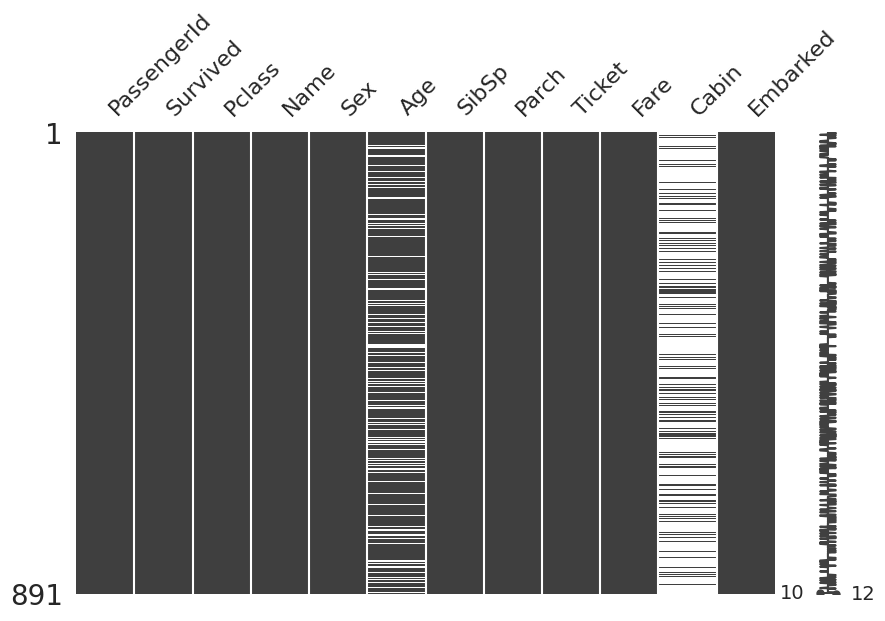

In [8]:
# Create a matrix visualization of missing values
msno.matrix(titanic,figsize=(10,6))

<Axes: >

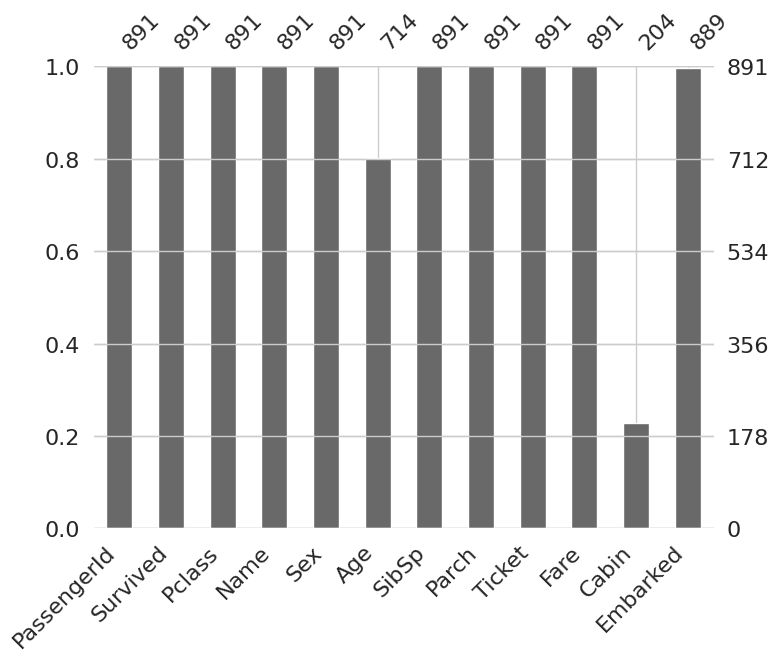

In [9]:
# Create a bar chart showing the count of missing values by column
msno.bar(titanic, figsize=(8,6))

<Axes: >

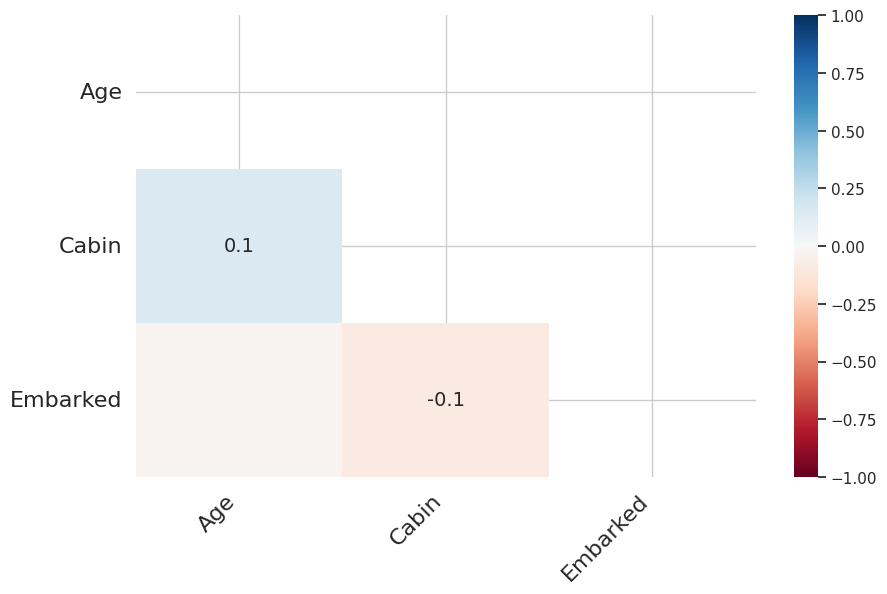

In [10]:
# Create a heatmap to show correlations between missingness
msno.heatmap(
    titanic,
    figsize=(10,6)
)

### What patterns of missingness can you see in the Titanic data set? Are there any relationships between missing values in different columns?

---Back to the slides!---

# 3. Deletion Methods

The simplest approach to handling missing data is to remove observations or variables with missing values.

### 3.1 Listwise Deletion (Complete-case analysis)

In [25]:
# Remove all rows with any missing values
# Check how many rows remain
backuptitanic = titanic.dropna()
backuptitanic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 1 to 889
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  183 non-null    int64  
 1   Survived     183 non-null    int64  
 2   Pclass       183 non-null    int64  
 3   Name         183 non-null    object 
 4   Sex          183 non-null    object 
 5   Age          183 non-null    float64
 6   SibSp        183 non-null    int64  
 7   Parch        183 non-null    int64  
 8   Ticket       183 non-null    object 
 9   Fare         183 non-null    float64
 10  Cabin        183 non-null    object 
 11  Embarked     183 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 18.6+ KB


In [33]:
print(f"Original data set size had {titanic.shape[0]} rows. \nNow it has only {backuptitanic.shape[0]}.")

Original data set size had 891 rows. 
Now it has only 183.


### 3.2 Column Deletion

In [37]:
# Create a copy of the original data set
deletedtitanic = titanic.copy()
# Remove columns with more than 30% missing values
threshold = .3
deletedtitanic = deletedtitanic.loc[:, deletedtitanic.isnull().mean() < threshold]
# Print the remaining columns
deletedtitanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


### 3.3 Dropping specific columns

Sometimes, we decide to drop specific columns based on domain knowledge or analysis requirements.

In [39]:
# Drop the 'Cabin' column
dropcabin = titanic.drop(columns=['Cabin'])
dropcabin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


### 3.4 Dropping specific rows (subset of columns)

In [42]:
# Drop rows where 'Age' is missing, but keep rows with missing values in other columns
titanic_age = titanic.dropna(subset = 'Age')
# Check how many rows remain
print(f"Rows first: {titanic.shape[0]}\nRows second: {titanic_age.shape[0]}")

Rows first: 891
Rows second: 714


### What are the advantages and disadvantages of the deletion methods you've implemented above?

---Back to the slides!---

# 4. Simple Imputation Methods

Instead of deleting data, we can replace missing values with estimates.

### 4.1 Mean/Median/Mode Imputation

In [50]:
# Create a copy of the original data set
titanic2 = titanic.copy()
# Impute missing values in the 'Age' column with the mean
meanage = titanic2["Age"].mean()
titanic2['Age'] = titanic2['Age'].fillna(meanage)
# Check that there are no missing values in the 'Age' column
titanic2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [54]:
# Create a copy of the original data set
titanic3 = titanic.copy()
# Impute missing values in the 'Age' column with the median
medianage = titanic['Age'].median()
# Check that there are no missing values in the 'Age' column
titanic3['Age'] = titanic3['Age'].fillna(medianage)

In [63]:
# Create a copy of the original data set
titanic4 = titanic.copy()
# Impute missing values in the 'Embarked' column with the mode
modeage = titanic['Embarked'].mode()[0]
titanic4['Embarked'] = titanic4['Embarked'].fillna(modeage)
# Check that there are no missing values in the 'Embarked' column
titanic4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Let's compare the distribution of `Age` before and after imputation.

In [59]:
# Compare the original and imputed age distributions
# Original age distribution (excluding missing values)
titanic['Age'].describe()
# Mean imputed age distribution
# Median imputed age distribution


,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


### 4.2 Constant Value Imputation

In [69]:
# Create a copy of the original data set
constant = titanic.copy()
# Impute missing 'Cabin' values with 'Unknown'
constant['Cabin'] = constant['Cabin'].fillna('Unknown')
# Check the result
constant['Cabin'].value_counts()


,count
Cabin,
Unknown,687
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
...,...
E17,1
A24,1
C50,1


### How do mean/median/mode imputation and constant imputation affect the distribution of the data? What are potential issues with these methods?

# 5. Imputation Based on Other Variables

More sophisticated imputation methods leverage relationships between variables to estimate missing values.

### 5.1 Imputation by Group

In [20]:
# Create a copy of the original data set
# Group passengers by class and gender, then impute age with the group mean
# Check if there are any missing age values left


Let's compare the age distribution after group imputation with the original data.

In [21]:
# Compare the original and group-imputed age distributions
# Plot histograms


### 5.2 Adding Missing Indicators

Creating indicator variables for missingness can help preserve information about the pattern of missing data.

In [22]:
# Create a copy of the original data set
# Add missing indicators for 'Age' and 'Cabin'
# Impute missing values
# Check the result


---Back to the slides!---

# 6. Handling Mixed Data Types

Real-world data sets often contain a mix of numerical and categorical variables. Let's implement a complete missing data handling strategy for the Titanic data set.

In [23]:
# Create a copy of the original data set
# Examine the data types


In [24]:
# Implement a complete missing data strategy
# 1. Drop columns with too many missing values
# 2. Handle numerical variables
# Group passengers by class and gender for more accurate imputation
    # Calculate group means
    # Impute missing values with group means
    # For any remaining missing values (rare groups), use overall mean
# 3. Handle categorical variables
# Impute 'Embarked' with mode
# 4. Check if there are any missing values left


# 7. Best Practices and Conclusion

Let's summarize best practices for handling missing data in Python:

### Best Practices for Handling Missing Data

1. **Understand the data**: Always start by exploring the extent and patterns of missingness.
2. **Consider the missingness mechanism**: Is the data MCAR, MAR, or MNAR? This influences your choice of handling method.
3. **Document your approach**: Keep track of how you handled missing data for transparency and reproducibility.
4. **Use appropriate methods for different variables**: Consider the type and importance of each variable.
5. **Create missing indicators**: For key variables, create indicator variables to preserve information about missingness.
6. **Compare different approaches**: Evaluate the impact of different methods on your analysis or model.
7. **Consider domain knowledge**: Incorporate subject matter expertise in your imputation strategy.
8. **Be cautious with deletion methods**: Only use deletion when data is MCAR or the amount of missingness is very small.
9. **Conduct sensitivity analysis**: Test how sensitive your conclusions are to different missing data handling approaches.

# 8. Now You Try

1. Load a data set of your choice (you can use any that we have seen so far, or one of your own) and identify missing values.
2. Visualize the pattern of missingness using `missingno`.
3. Implement at least three different imputation methods.
4. Evaluate and compare the methods based on their effect on your analysis results or model performance.
5. Develop a comprehensive strategy for handling missing data in the data set, taking into account the variable types and missingness patterns.

# 9. Conclusion

In this notebook, we've explored various techniques for handling missing data in Python using pandas and other libraries. We've learned how to identify, visualize, and address missing values using deletion and imputation methods. Remember that there's no one-size-fits-all approach to handling missing data, and the best strategy depends on the specific characteristics of your data set and the goals of your analysis.